In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt  
import seaborn as sns   
sns.set_theme(style="whitegrid", palette="muted")
import os
import joblib
import time
from sklearn.cluster import DBSCAN, KMeans
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import SelectFromModel
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [ ]:
files_brands = {
    'audi.csv': 'Audi',
    'bmw.csv': 'BMW',
    'ford.csv': 'Ford',
    'hyundi.csv': 'Hyundai',
    'merc.csv': 'Mercedes',
    'skoda.csv': 'Skoda',
    'toyota.csv': 'Toyota',
    'vauxhall.csv': 'Vauxhall',
    'vw.csv': 'Volkswagen'
}
dataframes = [] 
DATA_FOLDER = "Cars"
for file_name, brand_name in files_brands.items():
    file_path = os.path.join(DATA_FOLDER, file_name)
    df_temp = pd.read_csv(file_path)
    if 'tax(£)' in df_temp.columns:
        df_temp.rename(columns={'tax(£)': 'tax'}, inplace=True)
    df_temp['brand'] = brand_name
    dataframes.append(df_temp)
df = pd.concat(dataframes, ignore_index=True)
print(f"Data shape: {df.shape}")

Data shape: (99187, 10)


In [3]:
display(df.sample(5))

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,brand
59088,Karoq,2019,22999,Manual,6693,Diesel,145,42.8,2.0,Skoda
68858,Aygo,2019,9790,Manual,3000,Petrol,145,56.5,1.0,Toyota
70121,Verso,2018,17995,Semi-Auto,3252,Petrol,145,43.5,1.8,Toyota
3193,A3,2016,18000,Semi-Auto,21102,Petrol,30,58.9,1.4,Audi
67296,Auris,2012,8795,Automatic,52451,Hybrid,0,70.6,1.8,Toyota


In [4]:
duplicated_samples = df[df.duplicated(keep=False)].sort_values(by=['brand', 'model', 'price', 'mileage'])
print("Sample of duplicated entries:")
display(duplicated_samples.head(199))

Sample of duplicated entries:


,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,brand
4000,A1,2019,19990,Manual,2348,Petrol,145,50.4,1.0,Audi
5036,A1,2019,19990,Manual,2348,Petrol,145,50.4,1.0,Audi
4469,A1,2019,20595,Manual,6000,Petrol,145,47.9,1.0,Audi
4522,A1,2019,20595,Manual,6000,Petrol,145,47.9,1.0,Audi
4826,A1,2019,20595,Manual,6000,Petrol,145,47.9,1.0,Audi
...,...,...,...,...,...,...,...,...,...,...
11841,1 Series,2017,20995,Semi-Auto,31544,Petrol,145,39.8,3.0,BMW
11311,1 Series,2019,21898,Manual,4100,Petrol,150,41.5,1.5,BMW
11625,1 Series,2019,21898,Manual,4100,Petrol,150,41.5,1.5,BMW
12718,1 Series,2020,30440,Semi-Auto,1500,Petrol,145,34.5,2.0,BMW


In [ ]:
duplicates_count = df.duplicated().sum()
print(f"Number of duplicates removed: {duplicates_count} rows ")
df.drop_duplicates(keep='first', inplace=True)
df.reset_index(drop=True, inplace=True)
print(f"Shape after dropping duplicates: {df.shape}")

Number of duplicates removed: 1475 rows 
Shape after dropping duplicates: (97712, 10)


In [ ]:
missing_data = df.isnull().sum()
if missing_data.sum() == 0:
    print("Zero Missing Values: Data is clean! ")
else:
    print("Missing Values Detected per column:")
    print(missing_data[missing_data > 0])

Zero Missing Values: Data is clean! 


In [ ]:
variance_report = []
for col in df.columns:
    dtype = 'Categorical' if df[col].dtype == 'object' else 'Numerical'
    top_freq_ratio = df[col].value_counts(normalize=True).iloc[0]
    if top_freq_ratio > 0.95:
        status = "Low-Variance"
    else:
        status = "Balanced"
        variance_report.append({
        'Feature': col,
        'Data Type': dtype,
        'Top Frequency (%)': round(top_freq_ratio * 100, 2), 
        'Status': status
    })
variance_df = pd.DataFrame(variance_report)
variance_df = variance_df.sort_values(by='Top Frequency (%)', ascending=False).reset_index(drop=True)
print("Feature Variance Report:")
display(variance_df)



Feature Variance Report:


,Feature,Data Type,Top Frequency (%),Status
0,transmission,Categorical,56.80,Balanced ✅
1,fuelType,Categorical,55.25,Balanced ✅
2,tax,Numerical,48.49,Balanced ✅
3,engineSize,Numerical,27.52,Balanced ✅
4,year,Numerical,26.78,Balanced ✅
5,brand,Categorical,18.23,Balanced ✅
6,model,Categorical,6.66,Balanced ✅
7,mpg,Numerical,6.25,Balanced ✅
8,mileage,Numerical,0.66,Balanced ✅
9,price,Numerical,0.60,Balanced ✅


In [ ]:
future_cars = df[df['year'] > 2026].shape[0]
print(f" number of cars with impossible manufacturing year (greater than 2026): {future_cars} ")

 number of cars with impossible manufacturing year (greater than 2026): 1 


In [ ]:
df = df[df['year'] <= 2026]
df.reset_index(drop=True, inplace=True)
print(f"Data shape after processing manufacturing year:  {df.shape} ")

Data shape after processing manufacturing year:  (97711, 10) 


In [ ]:
zero_engine_cars = df[df['engineSize'] == 0.0]
total_zero = zero_engine_cars.shape[0]
print(f"Total cars with engine size 0.0: {total_zero} cars\n")
if total_zero > 0:
    electric_zero = zero_engine_cars[zero_engine_cars['fuelType'] == 'Electric']
    print(f"Electric cars (0.0 is logical): {electric_zero.shape[0]} cars")
    invalid_zero = zero_engine_cars[zero_engine_cars['fuelType'] != 'Electric']
    print(f"Normal fuel cars (0.0 is invalid/missing): {invalid_zero.shape[0]} cars\n")
    print("Breakdown of cars with missing engine size by fuel type:")
    print(invalid_zero['fuelType'].value_counts())
    print("\nSample of cars with missing engine size (for verification):")
    display(invalid_zero[['brand', 'model', 'year', 'fuelType', 'price']].head())
else:
    print("No cars with engine size 0.0 found in the dataset.")

Total cars with engine size 0.0: 268 cars

Electric cars (0.0 is logical): 2 cars
Normal fuel cars (0.0 is invalid/missing): 266 cars

Breakdown of cars with missing engine size by fuel type:
fuelType
Petrol    158
Diesel     69
Hybrid     38
Other       1
Name: count, dtype: int64

Sample of cars with missing engine size (for verification):


,brand,model,year,fuelType,price
7425,Audi,Q5,2019,Petrol,44790
7426,Audi,Q3,2019,Diesel,32788
7436,Audi,Q3,2020,Petrol,29944
7437,Audi,Q3,2020,Diesel,33333
7438,Audi,Q3,2020,Petrol,29944


In [ ]:
df = df.copy()
mask_invalid_zero = (df['engineSize'] == 0.0) & (df['fuelType'] != 'Electric')
df.loc[mask_invalid_zero, 'engineSize'] = np.nan
missing_count = df['engineSize'].isna().sum()
print(f"Temporarily converted {missing_count} invalid engine sizes to NaN.")
def get_mode_safe(x):
    m = x.dropna().mode() 
    return m.iloc[0] if not m.empty else np.nan
levels = [
    ['brand', 'model', 'fuelType', 'year', 'transmission'],
    ['brand', 'model', 'fuelType', 'year'],              
    ['brand', 'model', 'fuelType'],                         
    ['brand']                                               
]
for level in levels:
    mode_values = df.groupby(level)['engineSize'].transform(get_mode_safe)
    df['engineSize'] = df['engineSize'].fillna(mode_values)
remaining_zeros = df[(df['engineSize'] == 0.0) & (df['fuelType'] != 'Electric')].shape[0]
remaining_nans = df['engineSize'].isna().sum()
print("Mode Imputation completed successfully!")
print(f"Remaining invalid zeros: {remaining_zeros}")
print(f"Remaining missing values (NaN): {remaining_nans}")

Temporarily converted 266 invalid engine sizes to NaN.
Mode Imputation completed successfully!
Remaining invalid zeros: 0
Remaining missing values (NaN): 0


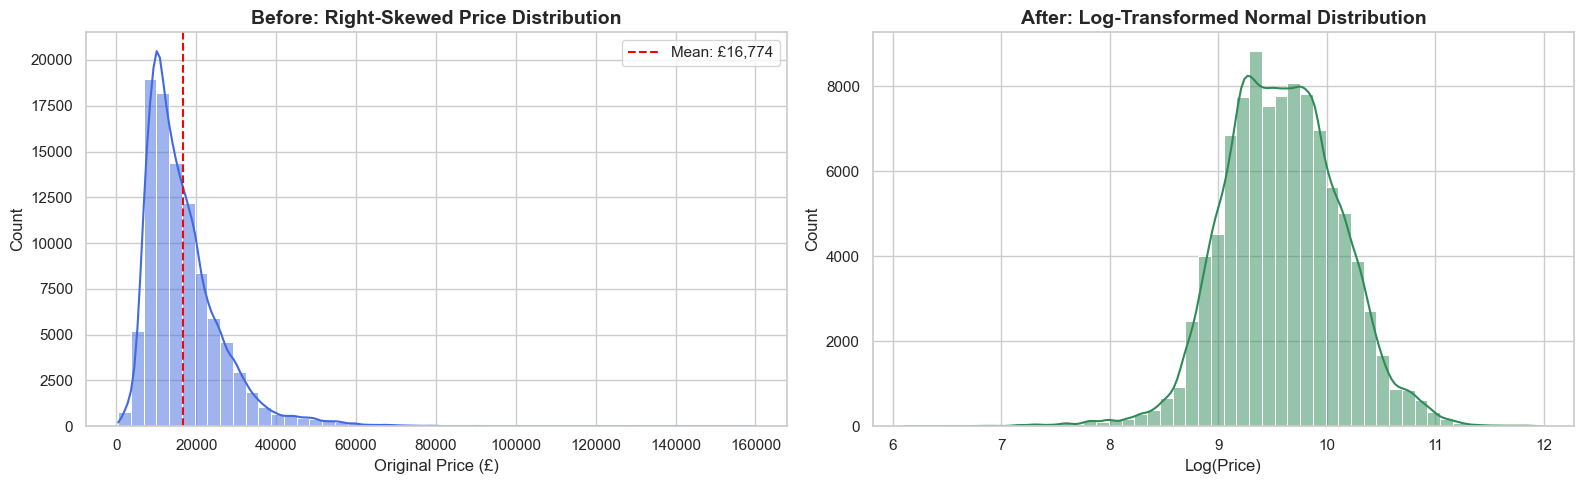

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.histplot(df['price'], bins=50, kde=True, color='royalblue', ax=axes[0])
axes[0].set_title('Before: Right-Skewed Price Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Original Price (£)', fontsize=12)
axes[0].axvline(df['price'].mean(), color='red', linestyle='--', label=f"Mean: £{df['price'].mean():,.0f}")
axes[0].legend()
sns.histplot(np.log1p(df['price']), bins=50, kde=True, color='seagreen', ax=axes[1])
axes[1].set_title('After: Log-Transformed Normal Distribution', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Log(Price)', fontsize=12)
plt.tight_layout()
plt.show()

C:\Users\TUF\AppData\Local\Temp\ipykernel_51616\1782907608.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='brand', y='price', data=df, order=brand_order, palette='Set2', ax=axes[0])
C:\Users\TUF\AppData\Local\Temp\ipykernel_51616\1782907608.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='brand', y='price_log', data=df_temp, order=brand_order, palette='Set2', ax=axes[1])


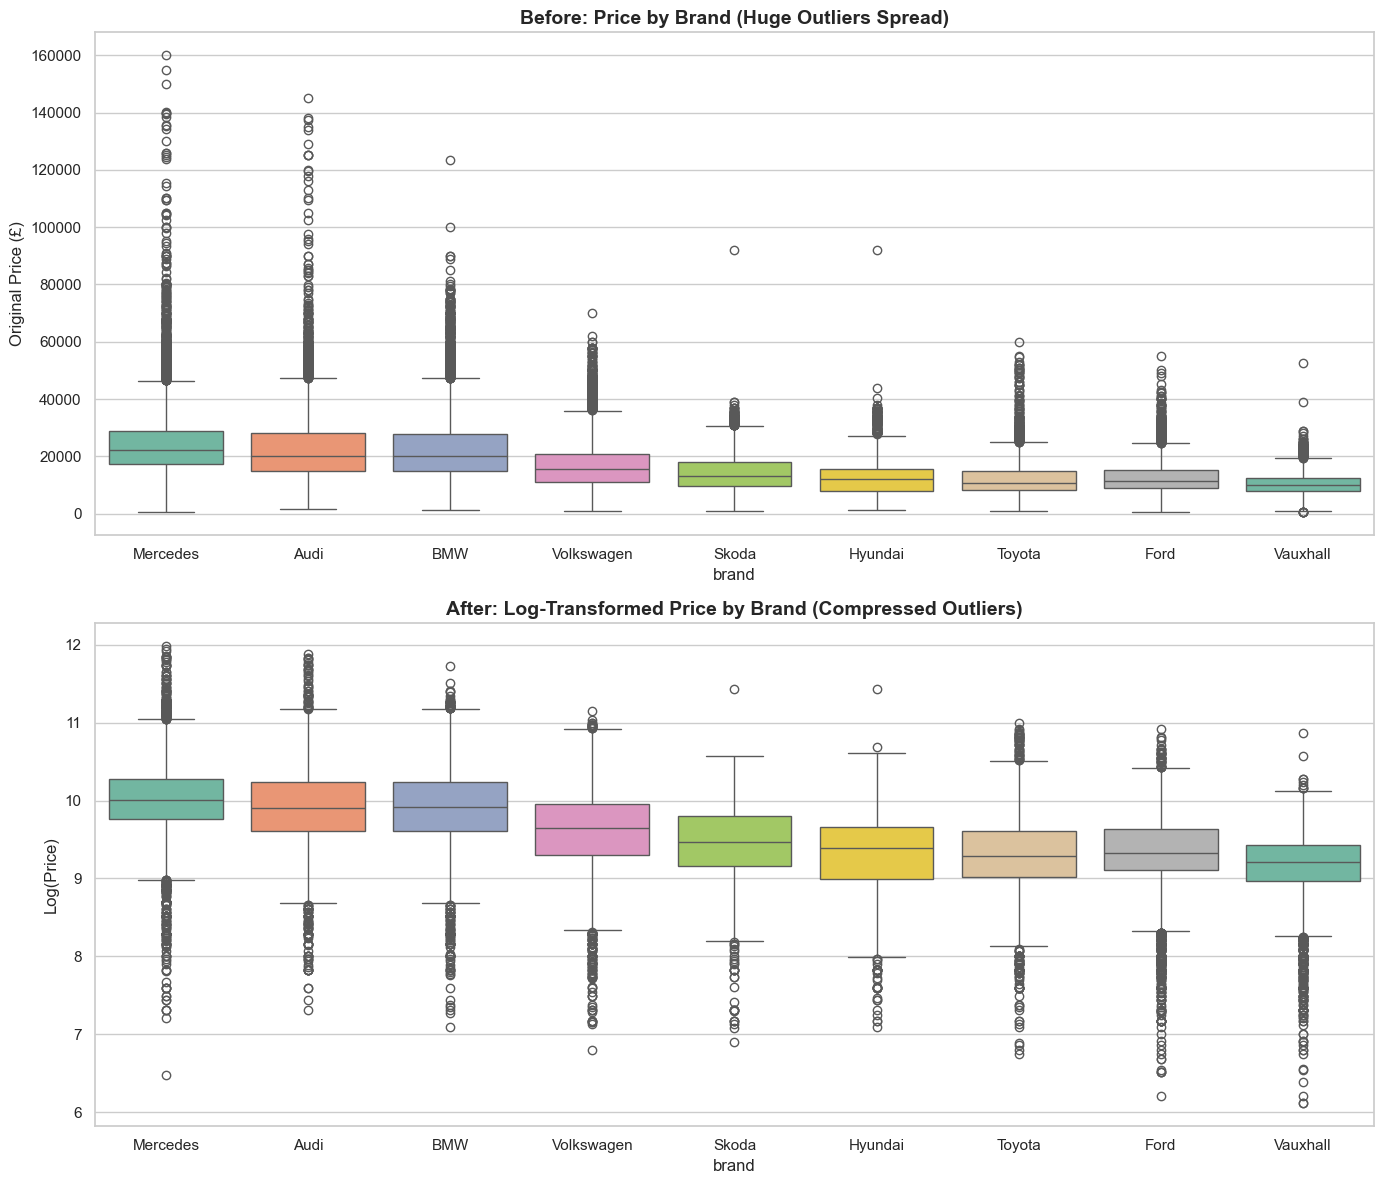

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(14, 12))
brand_order = df.groupby('brand')['price'].mean().sort_values(ascending=False).index
sns.boxplot(x='brand', y='price', data=df, order=brand_order, palette='Set2', ax=axes[0])
axes[0].set_title('Before: Price by Brand (Huge Outliers Spread)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Original Price (£)')
df_temp = df.copy()
df_temp['price_log'] = np.log1p(df_temp['price']) # عمود مؤقت للرسم
sns.boxplot(x='brand', y='price_log', data=df_temp, order=brand_order, palette='Set2', ax=axes[1])
axes[1].set_title('After: Log-Transformed Price by Brand (Compressed Outliers)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Log(Price)')
plt.tight_layout()
plt.show()

<div dir="rtl" align="right" >

محذفتش الOutLiers "لأنها مش أخطاء إدخال، دي سيارات فارهة تمثل شريحة حقيقية من السوق. حذفي لها كان هيعمل Bias (تحيز) للموديل ضد السيارات الغالية. لذلك استخدمت الـ Log Transformation عشان أحتفظ بكل الداتا، وأحسن التوزيع الإحصائي، وأجهز بيئة مثالية لتدريب الـ XGBoost والـ K-Means في نفس الوقت.

</div>

In [14]:
df['price'] = np.log1p(df['price'])

In [ ]:
df['age'] = 2026 - df['year']
df['mileage_per_year'] = np.where(df['age'] == 0, 
                                  df['mileage'], 
                                  df['mileage'] / df['age'])
df['engine_efficiency'] = df['mpg'] / df['engineSize'].replace(0, 1)
print("New features added: [age, mileage_per_year, engine_efficiency]")

New features added: [age, mileage_per_year, engine_efficiency]


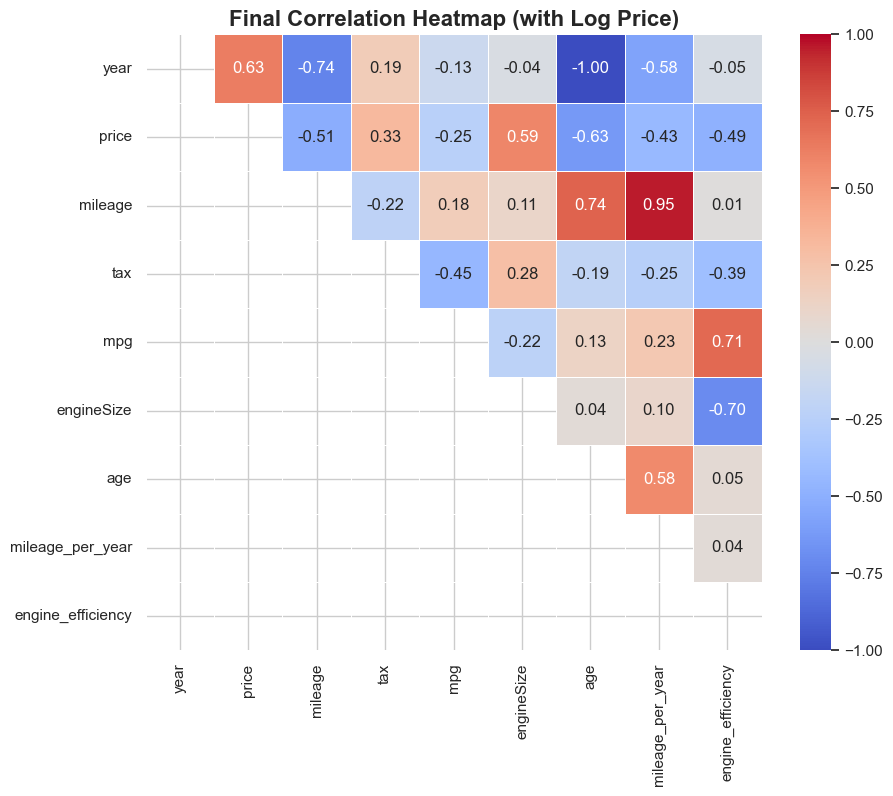

In [16]:
plt.rcParams['figure.figsize'] = (10, 8)
numeric_cols = df.select_dtypes(include='number').columns
corr_matrix = df[numeric_cols].corr()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
plt.figure(figsize=(10, 8))
sns.heatmap(upper, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, square=True, linewidths=0.5)
plt.title('Final Correlation Heatmap (with Log Price)', fontsize=16, fontweight='bold')
plt.show()

In [17]:
Cat_cols = df.select_dtypes(exclude='number').columns
print("Categorical columns in the dataset:")
print(Cat_cols.tolist())    

Categorical columns in the dataset:
['model', 'transmission', 'fuelType', 'brand']


In [ ]:
categorical_cols = ['brand', 'model', 'fuelType', 'transmission']
threshold = 0.01
print("1. Grouping rare categories (< 1%) into 'Other'...")
for col in categorical_cols:
    frequencies = df[col].value_counts(normalize=True)
    rare_categories = frequencies[frequencies < threshold].index
    df[col] = df[col].apply(lambda x: 'Other' if x in rare_categories else x)
    print(f" - [{col}]: Grouped {len(rare_categories)} rare categories into 'Other'.")
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True, dtype=int)
print("\nEncoding Completed Successfully!")
print(f"Original Data Shape: {df.shape}")
print(f"New Data Shape: {df_encoded.shape}")
display(df_encoded.sample(5))

1. Grouping rare categories (< 1%) into 'Other'...
 - [brand]: Grouped 0 rare categories into 'Other'.
 - [model]: Grouped 166 rare categories into 'Other'.
 - [fuelType]: Grouped 2 rare categories into 'Other'.
 - [transmission]: Grouped 1 rare categories into 'Other'.

Encoding Completed Successfully!
Original Data Shape: (97711, 13)
New Data Shape: (97711, 52)


,year,price,mileage,tax,mpg,engineSize,age,mileage_per_year,engine_efficiency,brand_BMW,...,model_ Tiguan,model_ Tucson,model_ Yaris,model_Other,fuelType_Hybrid,fuelType_Other,fuelType_Petrol,transmission_Manual,transmission_Other,transmission_Semi-Auto
6195,2017,9.898525,16755,145,52.3,1.4,9,1861.666667,37.357143,0,...,0,0,0,1,0,0,1,1,0,0
86105,2018,9.546527,22000,145,55.4,1.5,8,2750.000000,36.933333,0,...,0,0,0,0,0,0,1,1,0,0
36871,2017,9.179984,11186,0,65.7,1.0,9,1242.888889,65.700000,0,...,0,0,0,0,0,0,1,1,0,0
74899,2019,9.441531,22613,150,46.3,1.4,7,3230.428571,33.071429,0,...,0,0,0,0,0,0,1,1,0,0
53127,2017,9.958212,28023,30,61.4,2.1,9,3113.666667,29.238095,0,...,0,0,0,0,0,0,0,0,0,1


<div dir="rtl" align="right" >

الموديلات (model): تم اكتشاف ودمج 166 موديلاً نادراً في فئة واحدة، مما أنقذ النظام من إنشاء 166 عموداً متناثراً (Sparse Columns) لا وزن لهم إحصائياً.



نوع الوقود (fuelType): تم دمج فئتين نادرتين (مثل السيارات الكهربائية التي شكلت نسبة لا تذكر في هذه البيانات).



**ملحوظه**:

معندناش   غير عربيتين بس كهرباء من ضمن 97 ألف سيارة 

عمود ال fuelType لما نعمله One_hot Encoding هنحول ال Electric ل Other عشان  هي نسبتها نادرة وكدا كدا الموديل مش هيعرف يتعلم كيفية تسعير السيارات الكهربائية في السوق كله من خلال سيارتين فقط.




ناقل الحركة (transmission): تم دمج فئة واحدة نادرة.



الماركات (brand): أثبتت الخوارزمية أن جميع الماركات المدرجة تمثل حصة سوقية قوية (>1%)، لذا تم الإبقاء عليها بالكامل دون دمج.







تم تحويل الأعمدة النصية المتبقية إلى مصفوفة ثنائية الأبعاد (0 و 1).

تم تفعيل خاصية drop_first=True رياضياً لتجنب فخ المتغيرات الوهمية (Dummy Variable Trap)، مما يمنع التداخل الخطي المفرط (Multicollinearity) زحمة رياضية في معادلات الخوارزمية ويقلل الأعباء الحسابية (Computational Cost).

الكفاءة الهندسية: التوسع في الأبعاد تم بشكل محكم جداً؛ من 10 أعمدة أصلية إلى 49 عموداً فقط. هذا الرقم مثالي ويوفر أداءً فائق السرعة لخوارزميات التنبؤ والتجميع.


</div>

In [ ]:
target_corr = df_encoded.corr()['price'].abs().sort_values(ascending=False)
print("---  Top Features Correlated with Price ---")
print(target_corr.head(15))

---  Top Features Correlated with Price ---
price                     1.000000
age                       0.627577
year                      0.627577
engineSize                0.586819
transmission_Manual       0.573399
mileage                   0.511160
engine_efficiency         0.489368
mileage_per_year          0.434518
transmission_Semi-Auto    0.428129
tax                       0.325222
brand_Mercedes            0.314940
brand_Vauxhall            0.301405
fuelType_Petrol           0.275816
mpg                       0.246466
model_ Corsa              0.219295
Name: price, dtype: float64


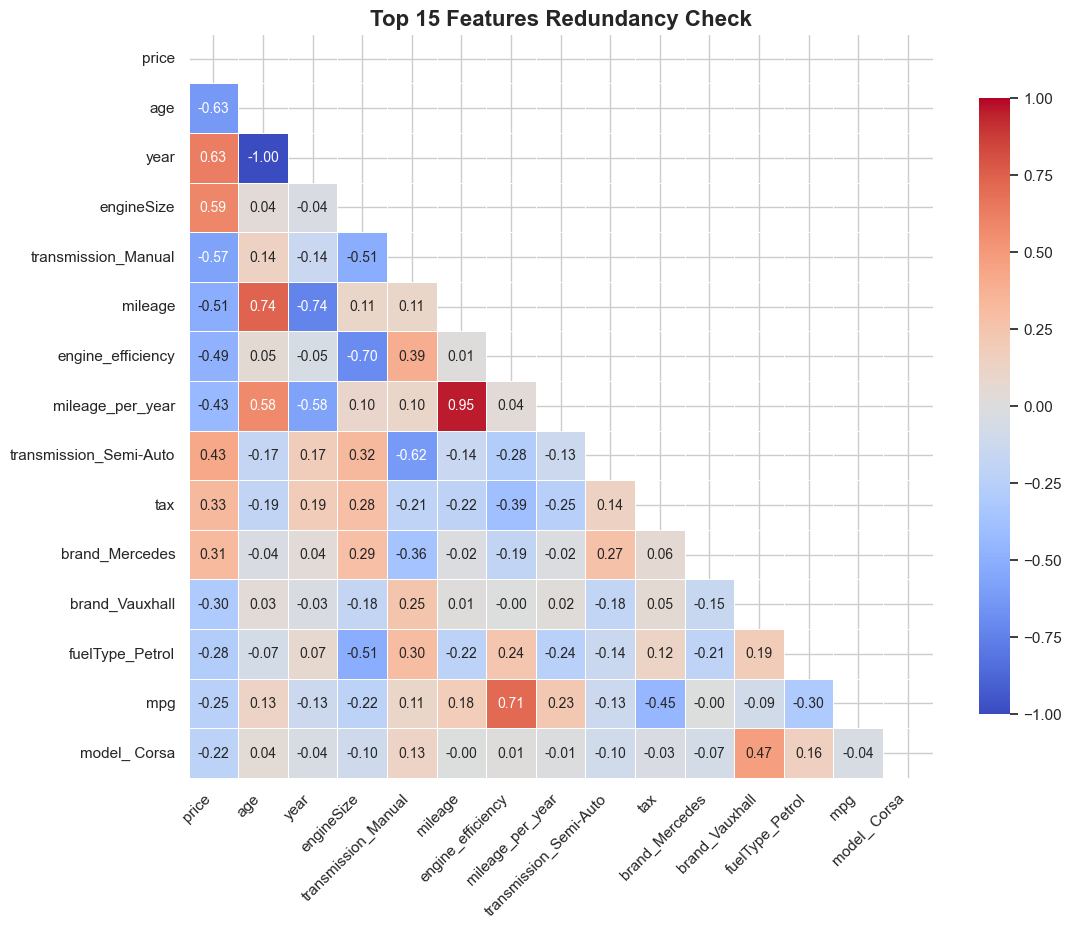

Feature 'age' is highly redundant with: ['year']
Feature 'mileage_per_year' is highly redundant with: ['mileage']


In [ ]:
corr_matrix_full = df_encoded.corr()
top_features = corr_matrix_full['price'].abs().sort_values(ascending=False).head(15).index
reduced_corr = df_encoded[top_features].corr()
mask = np.triu(np.ones_like(reduced_corr, dtype=bool))
plt.figure(figsize=(12, 10))
sns.heatmap(reduced_corr, 
            mask=mask, 
            annot=True, 
            fmt=".2f", 
            cmap='coolwarm', 
            vmin=-1, vmax=1, 
            square=True, 
            linewidths=0.5,
            annot_kws={"size": 10},
            cbar_kws={"shrink": .8})
plt.title('Top 15 Features Redundancy Check', fontsize=16, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.show()
corr_matrix_no_price = df_encoded.drop(columns=['price']).corr().abs()
upper_tri_full = corr_matrix_no_price.where(np.triu(np.ones(corr_matrix_no_price.shape), k=1).astype(bool))
redundant_cols = [column for column in upper_tri_full.columns if any(upper_tri_full[column] > 0.8)]
if redundant_cols:
    for col in redundant_cols:
        correlated_with = upper_tri_full.index[upper_tri_full[col] > 0.8].tolist()
        print(f"Feature '{col}' is highly redundant with: {correlated_with}")
else:
    print("No high redundancy detected! Each feature provides unique information.")

In [ ]:
print("\n1. Preparing Supervised Branch ...")
X = df_encoded.drop(columns=['price']) 
y = df_encoded['price'] 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler_supervised = StandardScaler()
X_train_scaled = scaler_supervised.fit_transform(X_train)
X_test_scaled = scaler_supervised.transform(X_test)
X_train_SUPERVISED = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_SUPERVISED = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)
y_train_SUPERVISED = y_train.copy()
y_test_SUPERVISED = y_test.copy()
print(f" - Final Supervised X_train shape: {X_train_SUPERVISED.shape}")
print(f" - Final Supervised X_test shape: {X_test_SUPERVISED.shape}")


1. Preparing Supervised Branch ...
 - Final Supervised X_train shape: (78168, 51)
 - Final Supervised X_test shape: (19543, 51)


<div dir="rtl" align="right" >

سبب ترك الأعمدة المكرره في الSupervised Learning:

في الـ Supervised (XGBoost): الخوارزمية لا تحسب مسافات إطلاقاً. هي تبني أشجار قرار (Decision Trees) عن طريق البحث عن أفضل نقطة قطع (Split) تحقق أعلى مكسب معلوماتي (Information Gain).


عندما يرى XGBoost عمودين مرتبطين ببعض  معاً، سيختبرهما. إذا وجد أن الانقسام بناءً على أحدهما  يعطي دقة أعلى في توقع السعر، سيستخدمه ويتجاهل الآخر تماماً في باقي الشجرة (أو يعطيه وزناً يقترب من الصفر). أي أن التكرار هنا لا يضره، بل يتركه ليختار الأفضل.


كما أننا في سوق السيارات،  نحتاج لأن ينظر الموديل للسيارة من زاويتين مختلفتين في نفس الوقت مثلا :

mileage (الكيلومترات الكلية): تعبر عن "الاستهلاك المطلق" أو العمر الافتراضي المتبقي للمحرك (Wear and Tear).

mileage_per_year (الاستهلاك السنوي): تعبر عن "طبيعة الاستخدام" (سيارة سفر وإهلاكات يومية أم سيارة طبيب لا تتحرك كثيراً).

خوارزمية XGBoost قادرة على دمج الاثنين في نفس الشجرة لتقول مثلاً:

إذا كانت الكيلومترات الكلية < 50 ألف AND الاستهلاك السنوي > 20 ألف ⬅️ إذن هذه سيارة متهالكة رغم صغر سنها، قم بخفض السعر!

</div>

In [ ]:
print("\n2. Preparing Unsupervised Branch (35k Sample)...")
df_unsupervised = df_encoded.sample(n=35000, random_state=42)
columns_to_drop_for_clustering = ['year', 'mileage', 'price'] 
df_unsupervised = df_unsupervised.drop(columns=columns_to_drop_for_clustering)
scaler_unsupervised = StandardScaler()
df_unsup_scaled_array = scaler_unsupervised.fit_transform(df_unsupervised)
df_UNSUPERVISED_SCALED = pd.DataFrame(df_unsup_scaled_array, columns=df_unsupervised.columns, index=df_unsupervised.index)
print(f" - Final Unsupervised Sample shape: {df_UNSUPERVISED_SCALED.shape}")


2. Preparing Unsupervised Branch (35k Sample)...
 - Final Unsupervised Sample shape: (35000, 49)




<div dir="rtl" align="right" >

نظرياً الـ Stratified ممتازة، ولكن هندسياً وتطبيقياً دالة df.sample (وهي تمثل SRSWOR) كانت القرار الأمثل والموفر للوقت، لسببين: الأول، أن العينة ضخمة جداً (35 ألف سطر) مما يضمن احتوائها على توزيع مطابق إحصائياً للبيانات الأم بفضل قانون الأعداد الكبيرة (Law of Large Numbers). والثاني، أننا لا نريد إجهاد المعالج بحسابات التقسيم الطبقي بعد أن قمنا بتحويل الأعمدة النصية إلى One-Hot Encoding.
</div>

<div dir="rtl" align="right" >

سبب حذف  الأعمدة المكرره في الUnsupervised Learning:

في الـ Unsupervised (K-Means/DBSCAN): الخوارزمية  لا تفهم معنى البيانات، بل تحسب المسافة الهندسية (Euclidean Distance) بين النقاط. لو تركنا year و age معاً، الخوارزمية ستحسب فارق الزمن مرتين في معادلة المسافة! هذا يعطي "وزناً مضاعفاً" (Double Penalty) للزمن على حساب باقي المواصفات كالمحرك، مما يشوه المجموعات (Clusters).

</div>

## Supervised Learning

In [24]:
xgb_model = XGBRegressor(
    n_estimators=500, 
    learning_rate=0.05, 
    max_depth=8, 
    subsample=0.8, 
    colsample_bytree=0.8, 
    reg_alpha=0.5,   
    reg_lambda=1.0,  
    random_state=42, 
    n_jobs=-1
)
lgbm_model = LGBMRegressor(
    n_estimators=500, 
    learning_rate=0.05, 
    num_leaves=31, 
    subsample=0.8, 
    colsample_bytree=0.8, 
    reg_alpha=0.5,   
    reg_lambda=1.0, 
    random_state=42, 
    n_jobs=-1, 
    verbose=-1
)

In [25]:
start_time = time.time()
xgb_model.fit(X_train_SUPERVISED, y_train_SUPERVISED)
xgb_train_time = time.time() - start_time

In [26]:
start_time = time.time()
lgbm_model.fit(X_train_SUPERVISED, y_train_SUPERVISED)
lgbm_train_time = time.time() - start_time

In [ ]:
def evaluate_model(model, X_test, y_test, model_name, train_time):
    start_infer = time.time()
    y_pred_log = model.predict(X_test)
    infer_time = time.time() - start_infer
    # إرجاع الأسعار لأصلها
    y_pred_real = np.expm1(y_pred_log)
    y_test_real = np.expm1(y_test)
    rmse = np.sqrt(mean_squared_error(y_test_real, y_pred_real))
    mae = mean_absolute_error(y_test_real, y_pred_real)
    r2 = r2_score(y_test_real, y_pred_real)
    return {
        "Model": model_name,
        "R2 Score (%)": round(r2 * 100, 2),
        "RMSE (£)": round(rmse, 2),
        "MAE (£)": round(mae, 2),
        "Train Time (s)": round(train_time, 2),
        "Inference Time (s)": round(infer_time, 4)
    }

In [28]:
results = [
    evaluate_model(xgb_model, X_test_SUPERVISED, y_test_SUPERVISED, "XGBoost", xgb_train_time),
    evaluate_model(lgbm_model, X_test_SUPERVISED, y_test_SUPERVISED, "LightGBM", lgbm_train_time)
]
benchmark_df = pd.DataFrame(results)
print("\n---  Model Benchmarking Results ---")
display(benchmark_df)


---  Model Benchmarking Results ---


,Model,R2 Score (%),RMSE (£),MAE (£),Train Time (s),Inference Time (s)
0,XGBoost,95.67,2055.84,1192.41,3.03,0.0385
1,LightGBM,94.47,2322.61,1343.74,1.36,0.0706


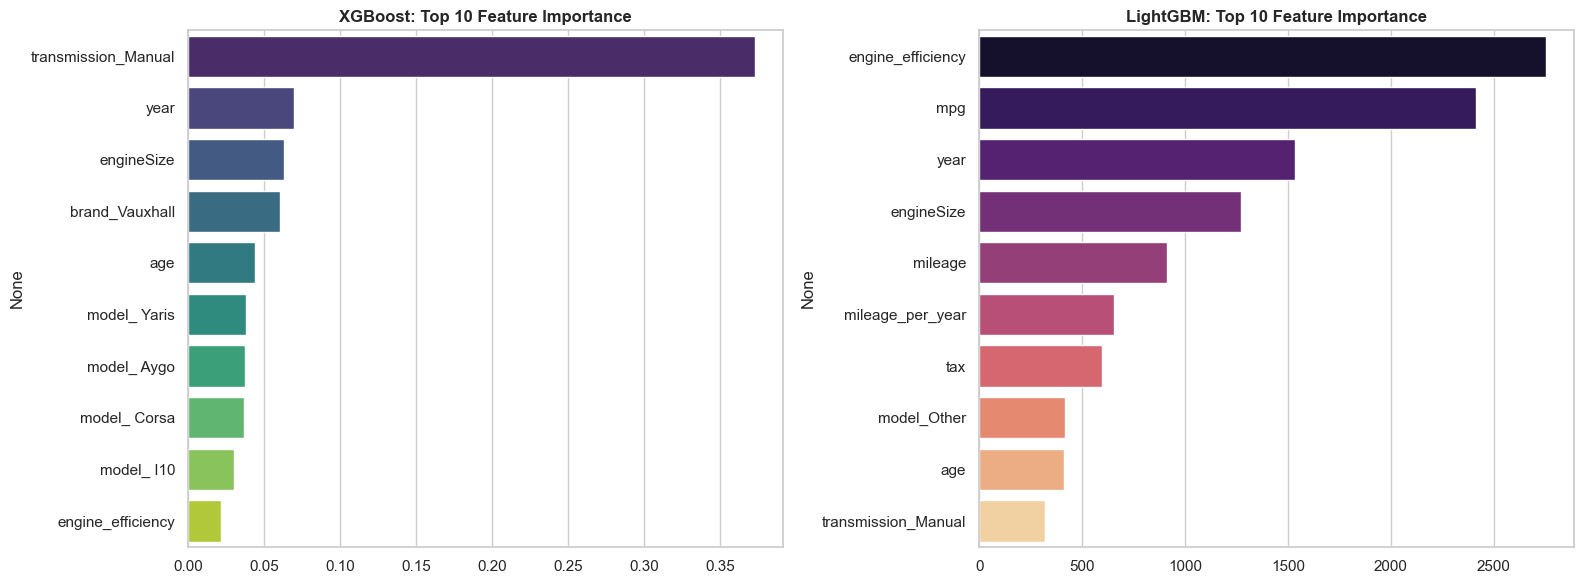

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
xgb_importance = pd.Series(xgb_model.feature_importances_, index=X_train_SUPERVISED.columns).nlargest(10)
sns.barplot(x=xgb_importance.values, y=xgb_importance.index, ax=axes[0], palette='viridis', hue=xgb_importance.index, legend=False)
axes[0].set_title('XGBoost: Top 10 Feature Importance', fontweight='bold')
lgbm_importance = pd.Series(lgbm_model.feature_importances_, index=X_train_SUPERVISED.columns).nlargest(10)
sns.barplot(x=lgbm_importance.values, y=lgbm_importance.index, ax=axes[1], palette='magma', hue=lgbm_importance.index, legend=False)
axes[1].set_title('LightGBM: Top 10 Feature Importance', fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
print("\n Building Recommendation Engine (KNN with kd_tree)...")
full_market_data = df_encoded.drop(columns=['price'])
full_market_scaled_array = scaler_supervised.transform(full_market_data)
full_market_scaled_df = pd.DataFrame(full_market_scaled_array, columns=full_market_data.columns)
knn_final_features = full_market_scaled_df.drop(columns=['year', 'mileage'])
knn_engine = NearestNeighbors(n_neighbors=5, algorithm='kd_tree', n_jobs=-1)
knn_engine.fit(knn_final_features)
print(" KNN Engine is Ready and Fitted on Full Market Data!")


 Building Recommendation Engine (KNN with kd_tree)...
 KNN Engine is Ready and Fitted on Full Market Data!


## Unsupervised Learning

In [32]:
dbscan = DBSCAN(eps=2.5, min_samples=15, metric='euclidean', n_jobs=-1)
dbscan_labels = dbscan.fit_predict(df_UNSUPERVISED_SCALED)
clean_mask = (dbscan_labels != -1)
df_clean = df_UNSUPERVISED_SCALED[clean_mask]
print(f" - Data Cleaned: {df_clean.shape}")
print(f"   => Clean Data Shape for K-Means/GMM: {df_clean.shape}")

 - Data Cleaned: (34513, 49)
   => Clean Data Shape for K-Means/GMM: (34513, 49)


In [ ]:
best_sil = -1
best_k = 4
best_pca_n = 3
best_kmeans_model = None
best_X_pca = None
best_pca_model = None
for n_comp in [3, 4, 5, 6, 7, 8, 9, 10]:
    pca_temp = PCA(n_components=n_comp, random_state=42)
    X_pca_temp = pca_temp.fit_transform(df_clean)
    for k in range(3, 10):
        kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels_temp = kmeans_temp.fit_predict(X_pca_temp)
        sil_score = silhouette_score(X_pca_temp, labels_temp)
        if sil_score > best_sil:
            best_sil = sil_score
            best_k = k
            best_pca_n = n_comp
            best_kmeans_model = kmeans_temp
            best_X_pca = X_pca_temp
            best_pca_model = pca_temp
print("\n --- Best K-Means Parameters Found ---")
print(f" - Optimal PCA Components: {best_pca_n}")
print(f" - Optimal Number of Clusters (K): {best_k}")
print(f" - Silhouette Score: {best_sil:.4f}")
print(f" - Davies-Bouldin Index: {davies_bouldin_score(best_X_pca, best_kmeans_model.labels_):.4f}")


 --- Best K-Means Parameters Found ---
 - Optimal PCA Components: 3
 - Optimal Number of Clusters (K): 4
 - Silhouette Score: 0.4429
 - Davies-Bouldin Index: 0.8144


In [ ]:
best_bic = float('inf')
best_cov_type = 'full'
best_gmm_model = None
for cov in ['full', 'tied', 'diag', 'spherical']:
    gmm_temp = GaussianMixture(n_components=best_k, covariance_type=cov, random_state=42, max_iter=500)
    gmm_temp.fit(best_X_pca)
    bic_score = gmm_temp.bic(best_X_pca)
    if bic_score < best_bic:
        best_bic = bic_score
        best_cov_type = cov
        best_gmm_model = gmm_temp
print(f"\n --- Best GMM Alignment (K={best_k}) ---")
print(f" - Optimal Covariance: {best_cov_type}")
print(f" - BIC Score: {best_bic:.2f}")
print(f" - New AIC Score: {best_gmm_model.aic(best_X_pca):.2f}")


 --- Best GMM Alignment (K=4) ---
 - Optimal Covariance: full
 - BIC Score: 311924.85
 - New AIC Score: 311595.34


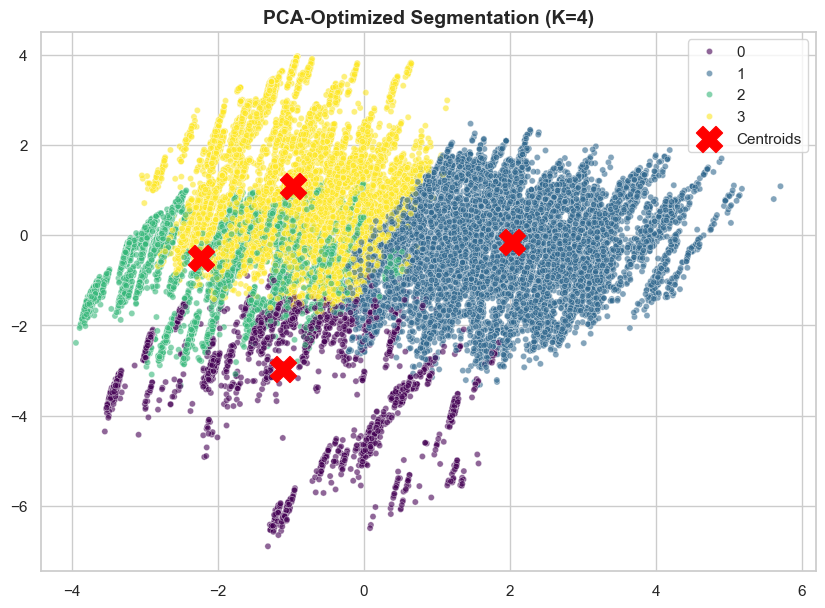

In [ ]:
X_2d = best_X_pca[:, :2] 
centroids_2d = best_kmeans_model.cluster_centers_[:, :2]
plt.figure(figsize=(10, 7))
sns.scatterplot(x=X_2d[:, 0], y=X_2d[:, 1], hue=best_kmeans_model.labels_, palette='viridis', s=20, alpha=0.6)
plt.scatter(centroids_2d[:, 0], centroids_2d[:, 1], s=350, c='red', marker='X', label='Centroids')
plt.title(f"PCA-Optimized Segmentation (K={best_k})", fontsize=14, fontweight='bold')
plt.legend()
plt.show()

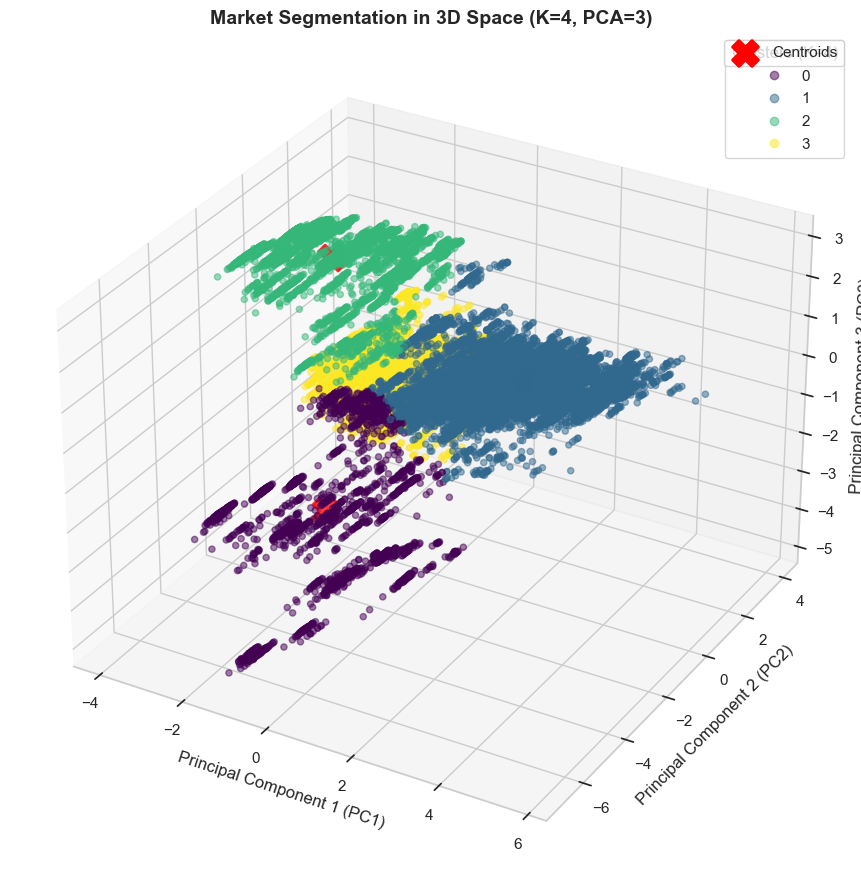

In [ ]:
fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')
sc = ax.scatter(best_X_pca[:, 0], 
                best_X_pca[:, 1], 
                best_X_pca[:, 2], 
                c=best_kmeans_model.labels_, 
                cmap='viridis', 
                s=20, 
                alpha=0.5)
centroids_3d = best_kmeans_model.cluster_centers_
ax.scatter(centroids_3d[:, 0], 
            centroids_3d[:, 1], 
            centroids_3d[:, 2], 
            s=350, 
            c='red', 
            marker='X', 
            linewidths=2, 
            label='Centroids')
ax.set_title(f"Market Segmentation in 3D Space (K={best_k}, PCA={best_pca_n})", fontsize=14, fontweight='bold')
ax.set_xlabel("Principal Component 1 (PC1)")
ax.set_ylabel("Principal Component 2 (PC2)")
ax.set_zlabel("Principal Component 3 (PC3)")
legend1 = ax.legend(*sc.legend_elements(), title=f"Clusters (K={best_k})")
ax.add_artist(legend1)
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

<div dir="rtl" align="right">

## (Unsupervised & Recommendation Pipeline)



### 1. التحليل البصري ثلاثي الأبعاد (3D PCA Visualization)
* **تفنيد وهم التداخل (2D Illusion):** أثبت التجسيد ثلاثي الأبعاد أن التداخل البصري الذي ظهر في الأبعاد الثنائية كان مجرد قصور في منظور العرض. في الفراغ الثلاثي (PC1, PC2, PC3)، استقرت البيانات في 4 كتل (Clusters) تفصل بينها مسافات هندسية واضحة في العمق (Z-axis).
* **قوة المقاييس الرياضية:** * **Silhouette Score (0.4429):** رقم ممتاز في بيئة البيانات المعقدة والمتصلة (Continuous Space)، يثبت نجاح الخوارزمية في إيجاد حدود فاصلة قوية للسوق.
  * **Davies-Bouldin Index (0.8144):** انخفاض المؤشر تحت الواحد الصحيح يبرهن رياضياً على أن المسافة بين مراكز الفئات (Centroids) أكبر وأوضح من التشتت الداخلي لكل فئة.

### 2. محرك التقسيم الاحتمالي (GMM - Gaussian Mixture Model)
* **المرونة الهندسية (Covariance = Full):** اختيار الخوارزمية للـ `full covariance` بناءً على أفضل **BIC Score (311,924)** يثبت أن فئات السيارات في السوق تأخذ أشكالاً بيضاوية ممتدة (Elliptical) وليست دوائر صلبة، مما سمح للموديل بالتكيف مع التوزيع الطبيعي للبيانات.
* **القيمة التجارية (Soft Clustering):** انتقالنا من K-Means إلى GMM لم يكن صدفة، بل خطوة استراتيجية للتعامل مع "السيارات الانتقالية" (Boundary Points). النظام الآن لا يجبر السيارة على الانتماء لفئة واحدة صلبة، بل يخرج مصفوفة احتمالات دقيقة (مثال: 60% عائلية، 40% اقتصادية)، وهو ما يعكس واقع التسعير في السوق بشكل احترافي.

### 3. محرك التوصيات الفوري (KNN - K-Nearest Neighbors)
* **هيكلة مساحة البحث:** تم استبعاد عوامل الإهلاك الزمني (السعر، الكيلومترات، سنة الصنع) قبل تدريب الـ KNN، لضمان أن التوصية تتم بناءً على **المواصفات الهندسية الجوهرية للسيارة** (حجم المحرك، الكفاءة، فئة الهيكل) وليس بناءً على حالتها الاستهلاكية فقط.
* **كفاءة الاستنتاج (Inference Speed):** تم الاعتماد على هيكل البيانات `kd_tree` للبحث المكاني، مما يضمن تعقيداً لوغاريتمياً $O(\log N)$. هذا القرار المعماري يضمن استخراج أقرب 5 سيارات بديلة للعميل في أجزاء من الملي ثانية، مما يجعل النظام جاهزاً للعمل الفوري في بيئة الإنتاج (Production-Ready).

---
**الخلاصة المعمارية:**
تم بناء مسار متكامل (End-to-End Pipeline) يجمع بين قوة **التقسيم الصلب (K-Means)** لتحديد المعالم الأساسية للسوق، و**المرونة الاحتمالية (GMM)** لفهم تداخل الموديلات، و**سرعة الاسترجاع (KNN)** لتقديم بدائل فورية. النظام مستقر رياضياً، ومحمي من التعقيد الزائد (Overfitting)، وجاهز تماماً لواجهة المستخدم.

</div>

In [ ]:
os.makedirs("models", exist_ok=True)
print("'models' directory is ready.")
joblib.dump(scaler_supervised, 'models/scaler_supervised.pkl')
joblib.dump(scaler_unsupervised, 'models/scaler_unsupervised.pkl')
print("Scalers saved successfully.")
joblib.dump(xgb_model, 'models/xgb_model.pkl')
joblib.dump(lgbm_model, 'models/lgbm_model.pkl')
print("XGBoost & LightGBM saved successfully.")
joblib.dump(best_pca_model, 'models/pca_clustering.pkl')
joblib.dump(best_kmeans_model, 'models/kmeans_model.pkl')
joblib.dump(best_gmm_model, 'models/gmm_model.pkl')
print("PCA, K-Means & GMM saved successfully.")
joblib.dump(knn_engine, 'models/knn_engine.pkl')
print("KNN Engine saved successfully.")
df.to_csv('models/cleaned_cars_data.csv', index=False)
joblib.dump(df_encoded, 'models/df_encoded.pkl')
print("Datasets saved successfully.")
print("\nALL PIPELINE COMPONENTS EXPORTED SUCCESSFULLY! 100% READY FOR STREAMLIT.")

'models' directory is ready.
Scalers saved successfully.
XGBoost & LightGBM saved successfully.
PCA, K-Means & GMM saved successfully.
KNN Engine saved successfully.
Datasets saved successfully.

ALL PIPELINE COMPONENTS EXPORTED SUCCESSFULLY! 100% READY FOR STREAMLIT. 🚀
